# WESAD End-to-End Modelling

**Goal**: Classify physiological states (Baseline / Stress / Amusement) using the WESAD dataset.  
Two main pipelines:

| Part | Input | Models |
|------|-------|--------|
| **A** – Tabular classification | Pre-extracted feature CSVs (`may14_feats4.csv`, `m14_merged.csv`) | Logistic Regression, Random Forest, XGBoost, Feed-forward MLP |
| **B** – Sequence classification | Raw wrist time-series from `.pkl` files | GRU / LSTM RNN |

Both parts use **Leave-One-Subject-Out (LOSO)** cross-validation so results reflect true subject-generalisation.

---
## 0 — Setup & Imports

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cu130
13.0


In [2]:
import os
os.environ['TORCHDYNAMO_DISABLE'] = '1'

import pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [3]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost not installed — XGBoost experiments will be skipped.\n'
          'Install with: pip install xgboost')

---
## 1 — Data Loading & Exploration

In [4]:
DATA_DIR = Path('data')

df_sensor = pd.read_csv(DATA_DIR / 'may14_feats4.csv', index_col=0)
df_merged = pd.read_csv(DATA_DIR / 'm14_merged.csv', index_col=0)

print('Sensor-only  :', df_sensor.shape)
print('With demographics:', df_merged.shape)

Sensor-only  : (1178, 48)
With demographics: (1178, 58)


In [5]:
print('\n--- Label distribution (original 3-class) ---')
LABEL_MAP = {0: 'Amusement', 1: 'Baseline', 2: 'Stress'}
print(df_sensor['label'].map(LABEL_MAP).value_counts())

print('\n--- Subjects ---')
print(sorted(df_sensor['subject'].unique()))
print(f'{df_sensor["subject"].nunique()} subjects total')


--- Label distribution (original 3-class) ---
label
Baseline     628
Stress       355
Amusement    195
Name: count, dtype: int64

--- Subjects ---
[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
15 subjects total


In [6]:
print('--- Windows per subject ---')
df_sensor.groupby('subject')['label'].value_counts().unstack(fill_value=0)

--- Windows per subject ---


label,0,1,2
subject,,,
2,13,41,22
3,13,41,23
4,13,41,22
5,13,43,23
6,13,42,23
7,13,42,23
8,13,42,24
9,13,42,23
10,13,42,26


---
# PART A — Tabular Classification

Each row is a 30-second window of summary statistics.  
We compare **two data variants** × **two label schemes** × **four models**.

### A.1 — Feature & Label Configuration

In [7]:
SENSOR_FEATS = [
    'BVP_mean', 'BVP_std', 'BVP_min', 'BVP_max',
    'EDA_phasic_mean', 'EDA_phasic_std', 'EDA_phasic_min', 'EDA_phasic_max',
    'EDA_smna_mean', 'EDA_smna_std', 'EDA_smna_min', 'EDA_smna_max',
    'EDA_tonic_mean', 'EDA_tonic_std', 'EDA_tonic_min', 'EDA_tonic_max',
    'Resp_mean', 'Resp_std', 'Resp_min', 'Resp_max',
    'TEMP_mean', 'TEMP_std', 'TEMP_min', 'TEMP_max',
    'TEMP_slope', 'BVP_peak_freq',
]

DEMO_FEATS = ['age', 'height', 'weight']

SENSOR_PLUS_DEMO = SENSOR_FEATS + DEMO_FEATS

print(f'Sensor features : {len(SENSOR_FEATS)}')
print(f'Sensor + demo   : {len(SENSOR_PLUS_DEMO)}')

Sensor features : 26
Sensor + demo   : 29


In [8]:
def to_binary(labels):
    """Amusement(0) & Baseline(1) -> 0 (Not-Stress), Stress(2) -> 1."""
    return (labels == 2).astype(int)

### A.2 — LOSO Evaluation Framework

In [9]:
def loso_evaluate(df, feature_cols, label_col, model_factory, binary=False):
    """
    Leave-One-Subject-Out evaluation.

    Parameters
    ----------
    df : DataFrame with 'subject', label_col, and feature_cols.
    feature_cols : list of column names to use as features.
    label_col : column name for the target.
    model_factory : callable that returns an sklearn-compatible model.
    binary : if True, binarise labels (stress vs rest).

    Returns
    -------
    results : dict with per-fold and aggregate metrics.
    """
    subjects = sorted(df['subject'].unique())
    fold_metrics = []
    all_y_true, all_y_pred = [], []

    for test_subj in subjects:
        train_mask = df['subject'] != test_subj
        test_mask = df['subject'] == test_subj

        X_train = df.loc[train_mask, feature_cols].values
        X_test = df.loc[test_mask, feature_cols].values
        y_train = df.loc[train_mask, label_col].values.copy()
        y_test = df.loc[test_mask, label_col].values.copy()

        if binary:
            y_train = to_binary(y_train)
            y_test = to_binary(y_test)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = model_factory()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        fold_metrics.append({'subject': test_subj, 'accuracy': acc, 'macro_f1': f1})
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    metrics_df = pd.DataFrame(fold_metrics)
    return {
        'per_fold': metrics_df,
        'mean_acc': metrics_df['accuracy'].mean(),
        'std_acc': metrics_df['accuracy'].std(),
        'mean_f1': metrics_df['macro_f1'].mean(),
        'std_f1': metrics_df['macro_f1'].std(),
        'y_true': np.array(all_y_true),
        'y_pred': np.array(all_y_pred),
    }

In [10]:
def print_results(name, res, target_names=None):
    print(f'\n{"="*60}')
    print(f' {name}')
    print(f'{"="*60}')
    print(f'  Mean Accuracy : {res["mean_acc"]:.4f} ± {res["std_acc"]:.4f}')
    print(f'  Mean Macro-F1 : {res["mean_f1"]:.4f} ± {res["std_f1"]:.4f}')
    print()
    print(classification_report(res['y_true'], res['y_pred'],
                                target_names=target_names, digits=3))


def plot_loso_bars(res, title):
    df_fold = res['per_fold']
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(x='subject', y='accuracy', data=df_fold, ax=axes[0], color='steelblue')
    axes[0].set_title(f'{title} — Accuracy by held-out subject')
    axes[0].set_ylim(0, 1.05)
    sns.barplot(x='subject', y='macro_f1', data=df_fold, ax=axes[1], color='coral')
    axes[1].set_title(f'{title} — Macro-F1 by held-out subject')
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def plot_confusion(res, title, target_names=None):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{title} — Aggregate Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

### A.3 — Model Factories

In [11]:
def make_lr():
    return LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')

def make_rf():
    return RandomForestClassifier(n_estimators=200, max_depth=10,
                                  class_weight='balanced', random_state=42)

def make_xgb():
    if not HAS_XGB:
        raise ImportError('xgboost not available')
    return XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                         use_label_encoder=False, eval_metric='mlogloss',
                         random_state=42, verbosity=0)

### A.4 — Run Sklearn Baselines (3-class)

In [36]:
MULTI_NAMES = ['Amusement', 'Baseline', 'Stress']

sklearn_results_multi = {}

for name, factory in [('LogReg', make_lr), ('RandomForest', make_rf)]:
    for tag, df_src, feat_list in [
        ('sensor', df_sensor, SENSOR_FEATS),
        ('sensor+demo', df_merged, SENSOR_PLUS_DEMO),
    ]:
        key = f'{name}_{tag}_3class'
        print(f'Running {key} ...')
        res = loso_evaluate(df_src, feat_list, 'label', factory, binary=False)
        sklearn_results_multi[key] = res
        print_results(key, res, MULTI_NAMES)

if HAS_XGB:
    for tag, df_src, feat_list in [
        ('sensor', df_sensor, SENSOR_FEATS),
        ('sensor+demo', df_merged, SENSOR_PLUS_DEMO),
    ]:
        key = f'XGBoost_{tag}_3class'
        print(f'Running {key} ...')
        res = loso_evaluate(df_src, feat_list, 'label', make_xgb, binary=False)
        sklearn_results_multi[key] = res
        print_results(key, res, MULTI_NAMES)

Running LogReg_sensor_3class ...

 LogReg_sensor_3class
  Mean Accuracy : 0.7194 ± 0.1721
  Mean Macro-F1 : 0.5883 ± 0.1802

              precision    recall  f1-score   support

   Amusement      0.410     0.221     0.287       195
    Baseline      0.723     0.817     0.767       628
      Stress      0.799     0.817     0.808       355

    accuracy                          0.718      1178
   macro avg      0.644     0.618     0.620      1178
weighted avg      0.694     0.718     0.700      1178

Running LogReg_sensor+demo_3class ...

 LogReg_sensor+demo_3class
  Mean Accuracy : 0.7175 ± 0.1671
  Mean Macro-F1 : 0.6070 ± 0.1808

              precision    recall  f1-score   support

   Amusement      0.450     0.344     0.390       195
    Baseline      0.739     0.777     0.758       628
      Stress      0.783     0.814     0.798       355

    accuracy                          0.716      1178
   macro avg      0.657     0.645     0.649      1178
weighted avg      0.705     0.716

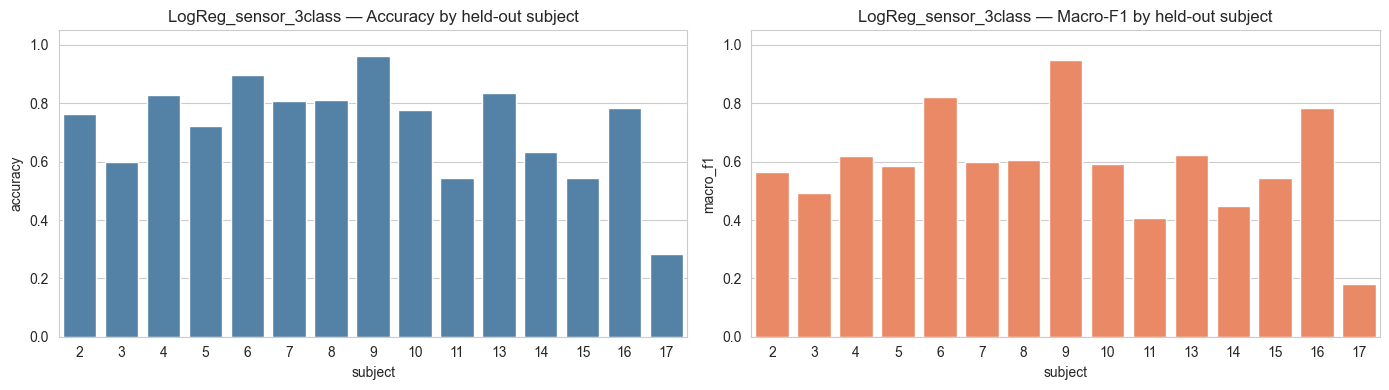

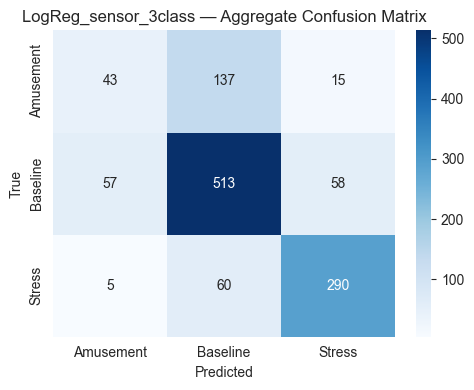

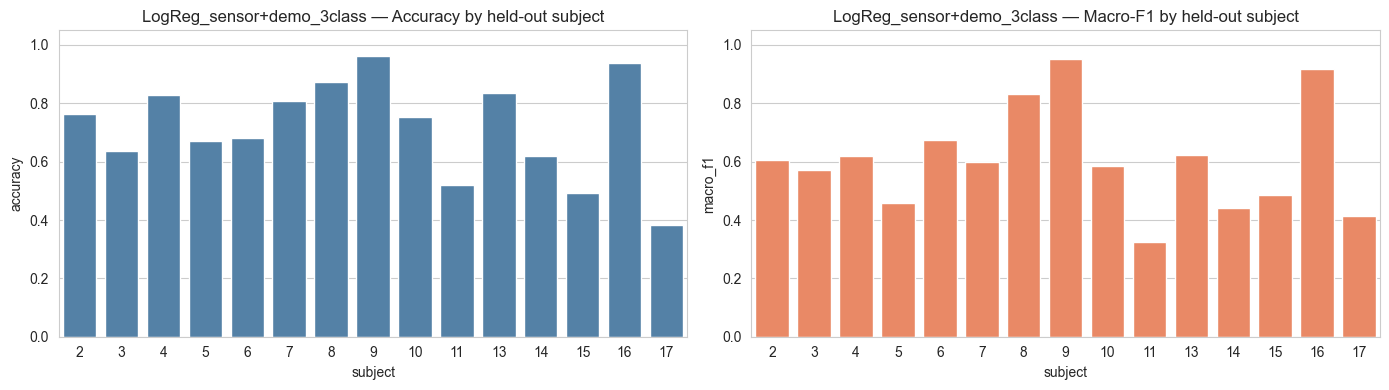

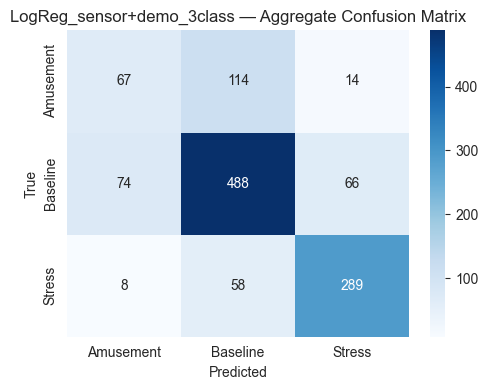

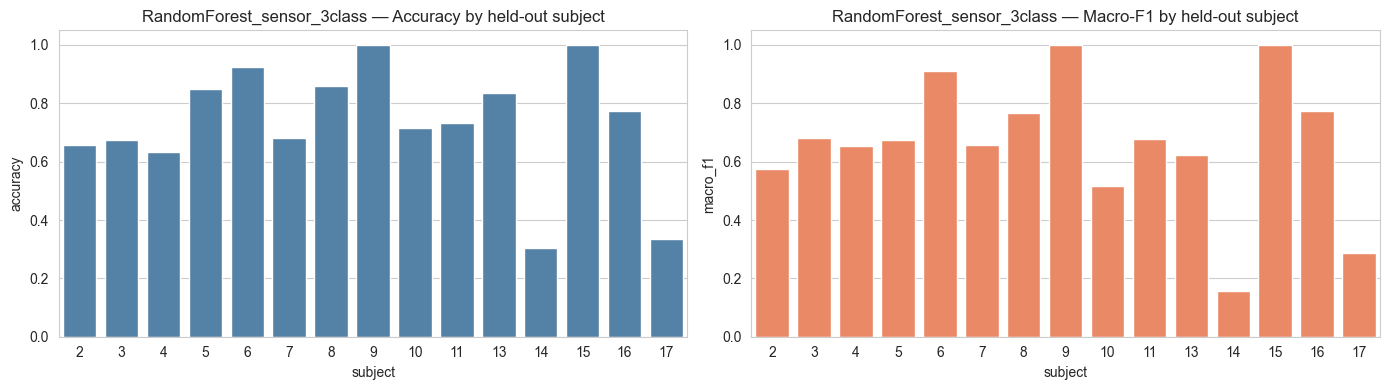

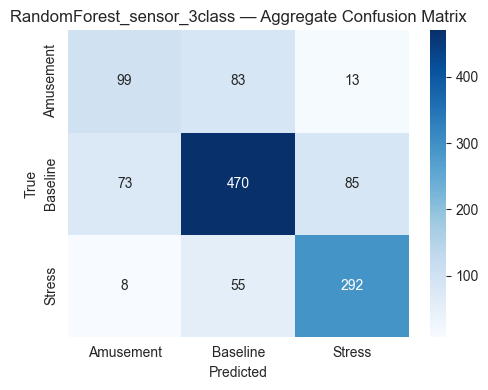

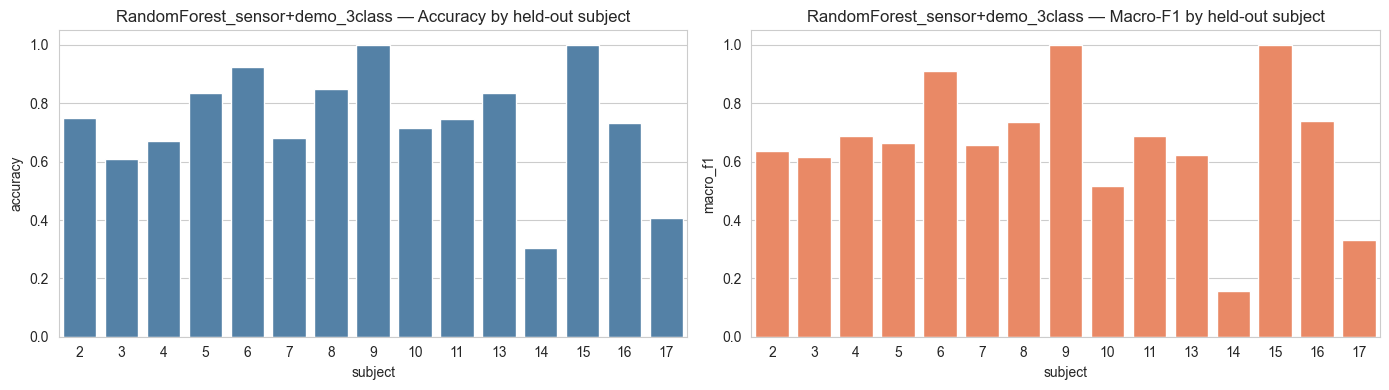

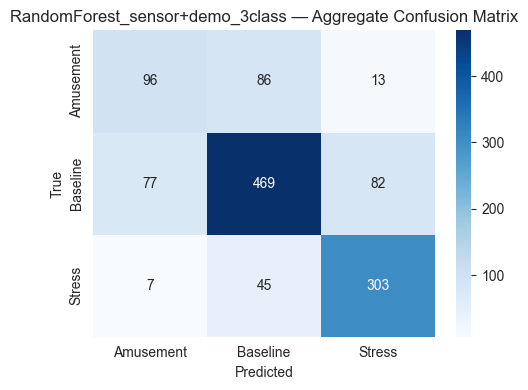

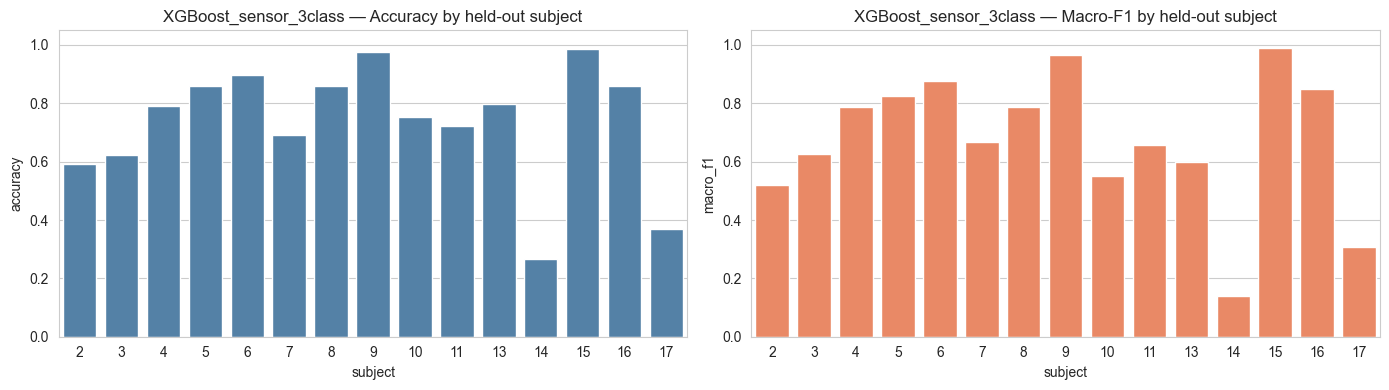

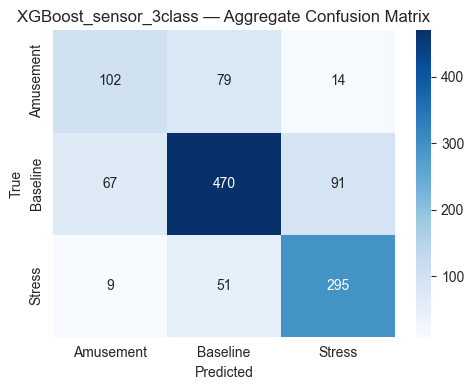

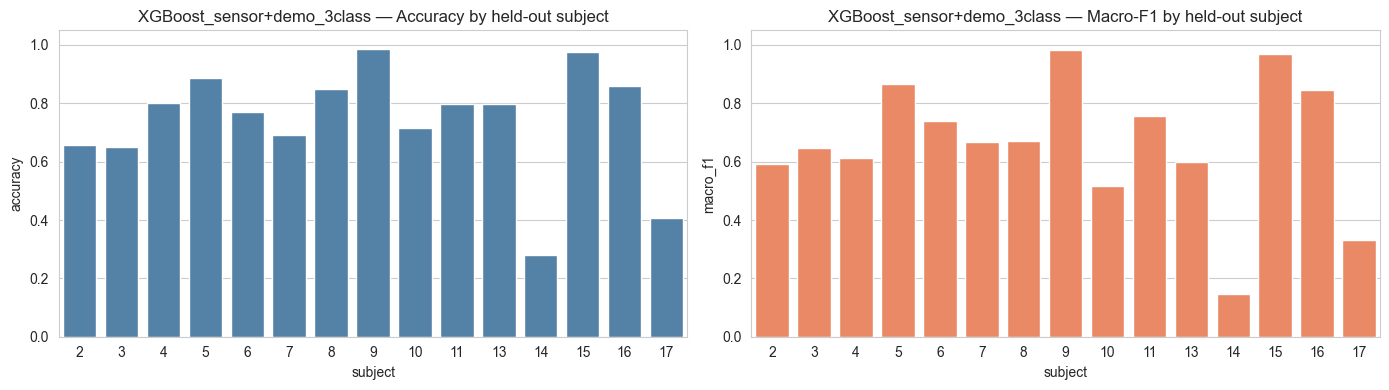

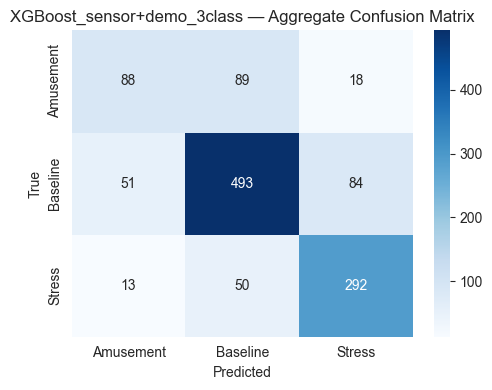

In [37]:
for key, res in sklearn_results_multi.items():
    plot_loso_bars(res, key)
    plot_confusion(res, key, MULTI_NAMES)

### A.5 — Run Sklearn Baselines (Binary: Stress vs Rest)

In [38]:
BIN_NAMES = ['Not-Stress', 'Stress']

sklearn_results_bin = {}

factories = [('LogReg', make_lr), ('RandomForest', make_rf)]
if HAS_XGB:
    factories.append(('XGBoost', make_xgb))

for name, factory in factories:
    for tag, df_src, feat_list in [
        ('sensor', df_sensor, SENSOR_FEATS),
        ('sensor+demo', df_merged, SENSOR_PLUS_DEMO),
    ]:
        key = f'{name}_{tag}_binary'
        print(f'Running {key} ...')
        res = loso_evaluate(df_src, feat_list, 'label', factory, binary=True)
        sklearn_results_bin[key] = res
        print_results(key, res, BIN_NAMES)

Running LogReg_sensor_binary ...

 LogReg_sensor_binary
  Mean Accuracy : 0.8864 ± 0.1610
  Mean Macro-F1 : 0.8655 ± 0.1875

              precision    recall  f1-score   support

  Not-Stress      0.914     0.922     0.918       823
      Stress      0.816     0.800     0.808       355

    accuracy                          0.885      1178
   macro avg      0.865     0.861     0.863      1178
weighted avg      0.885     0.885     0.885      1178

Running LogReg_sensor+demo_binary ...

 LogReg_sensor+demo_binary
  Mean Accuracy : 0.8729 ± 0.1617
  Mean Macro-F1 : 0.8526 ± 0.1767

              precision    recall  f1-score   support

  Not-Stress      0.913     0.903     0.908       823
      Stress      0.780     0.800     0.790       355

    accuracy                          0.872      1178
   macro avg      0.846     0.851     0.849      1178
weighted avg      0.873     0.872     0.872      1178

Running RandomForest_sensor_binary ...

 RandomForest_sensor_binary
  Mean Accuracy : 

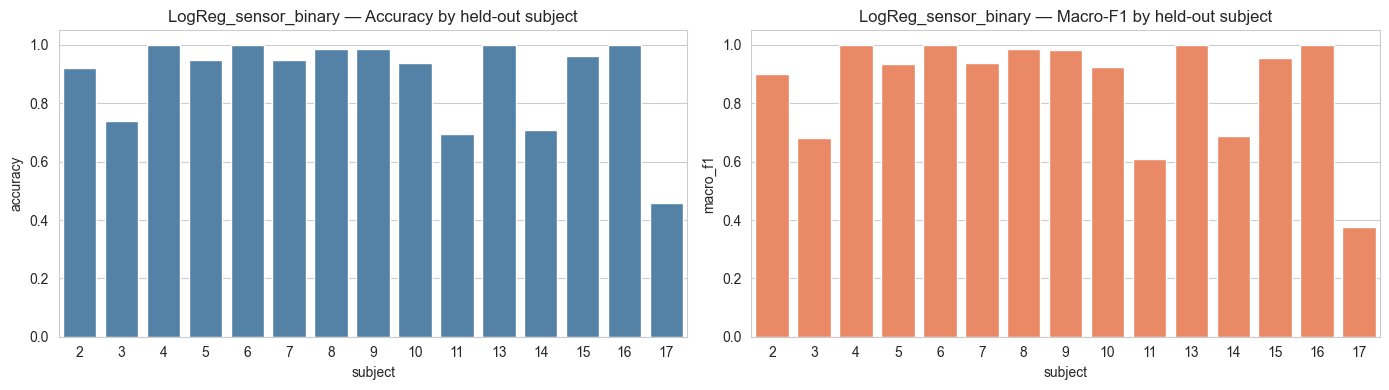

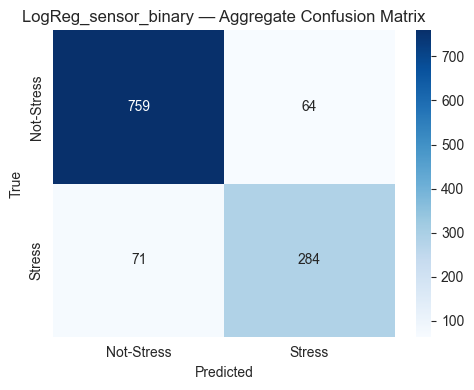

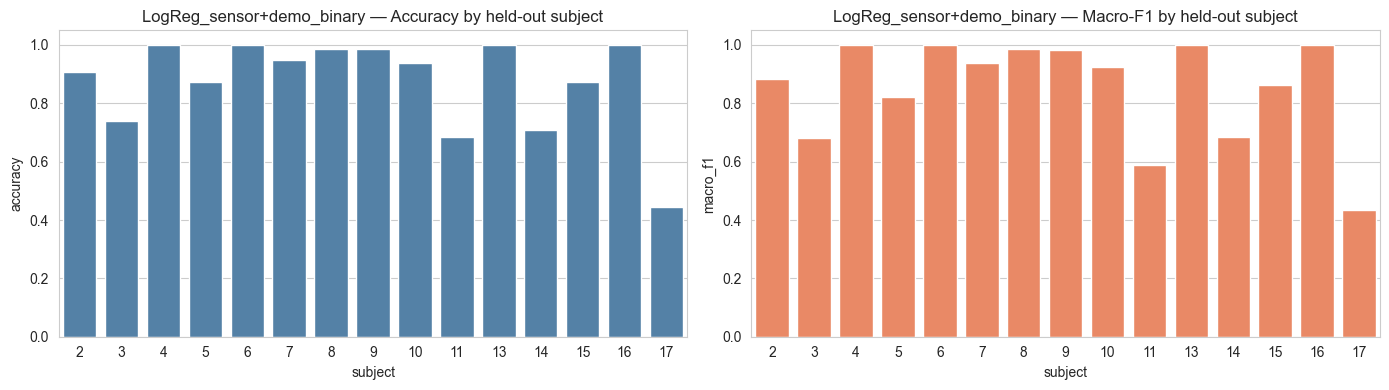

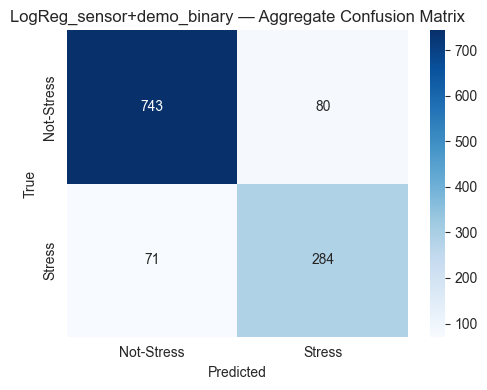

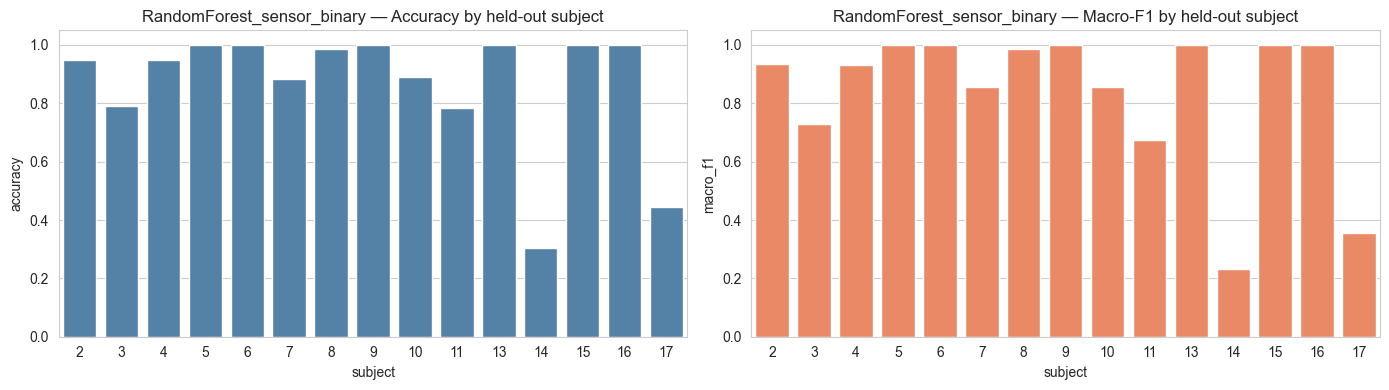

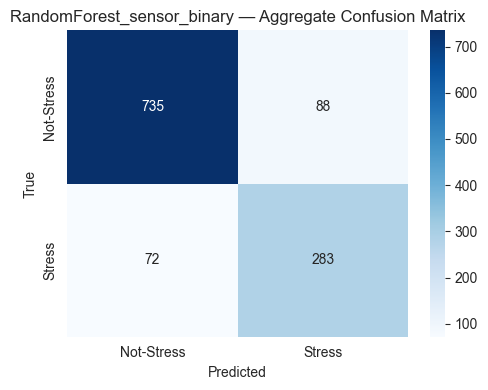

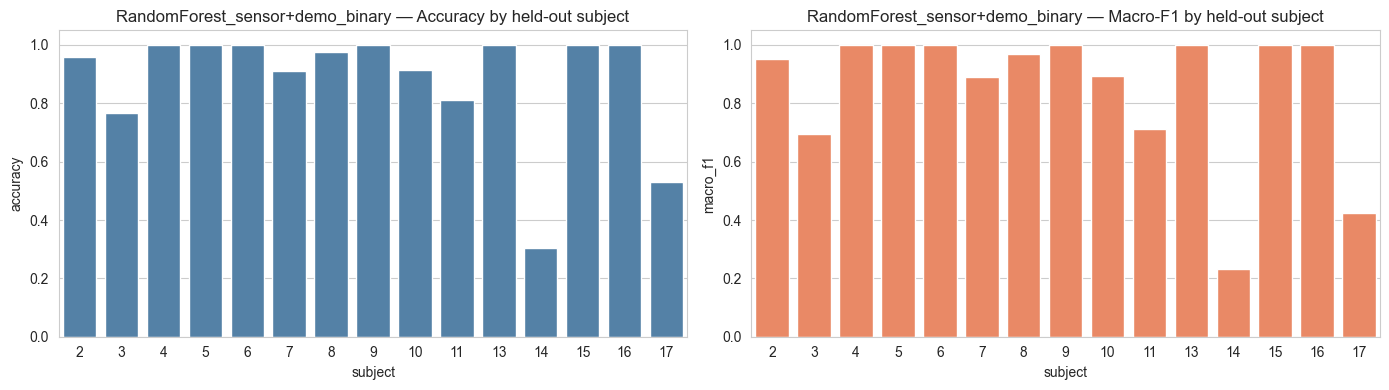

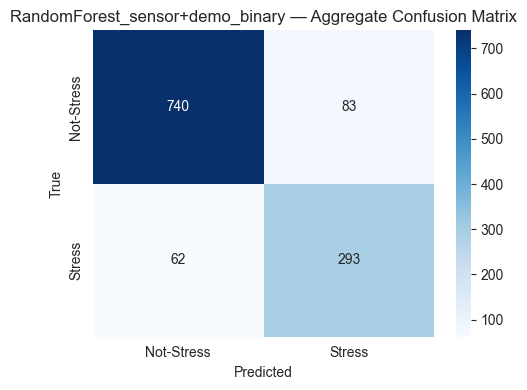

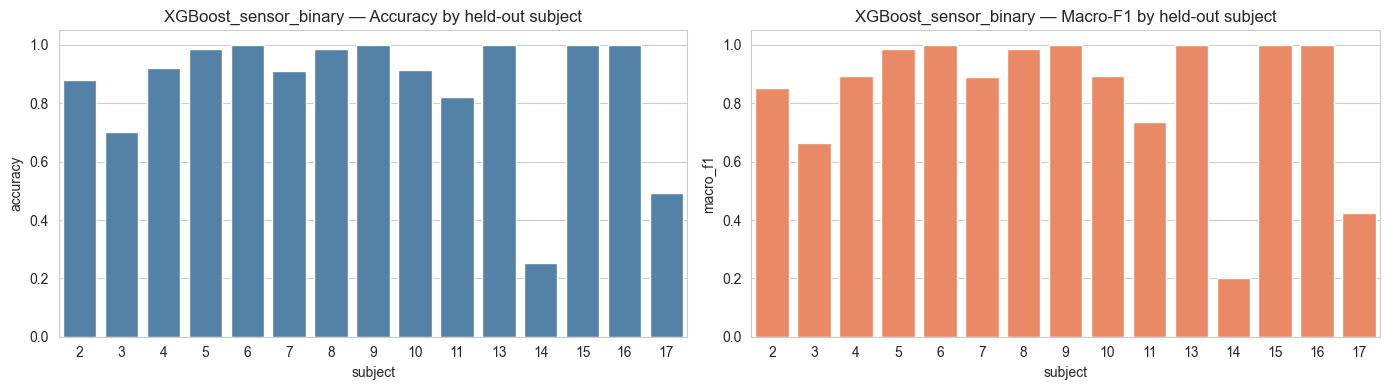

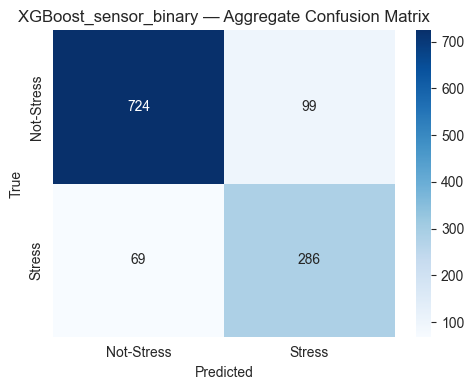

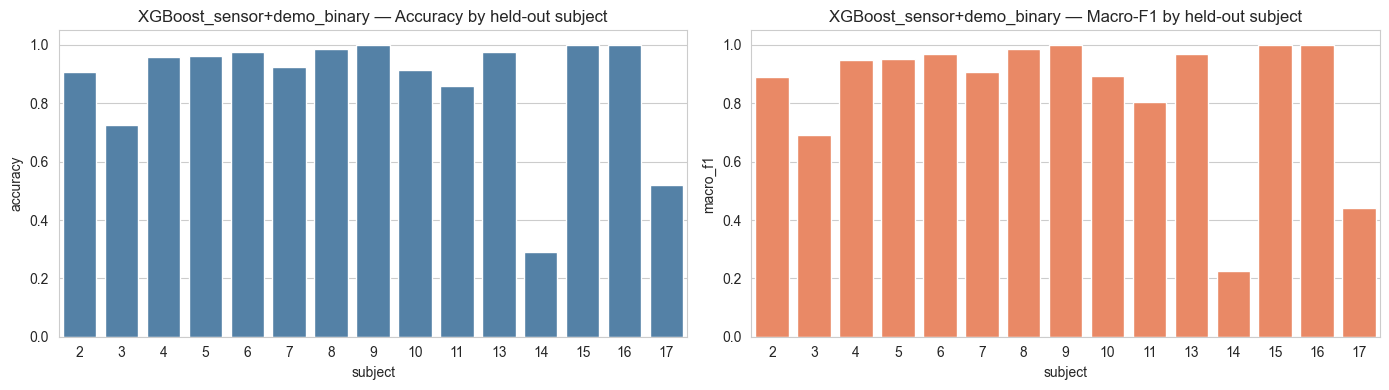

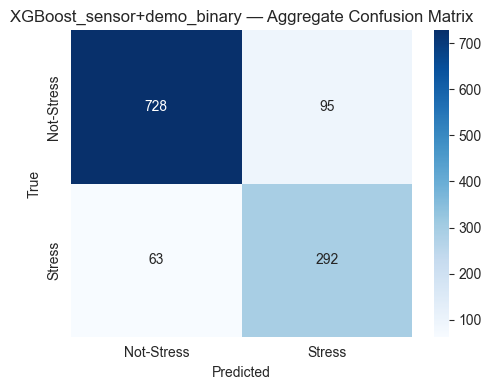

In [39]:
for key, res in sklearn_results_bin.items():
    plot_loso_bars(res, key)
    plot_confusion(res, key, BIN_NAMES)

### A.6 — Feed-Forward MLP (PyTorch) with LOSO

Replicates the `StressNet` architecture from your existing notebooks but with:
- Proper standardisation (fit on train fold only)
- `NLLLoss` paired with `LogSoftmax` (or raw logits + `CrossEntropyLoss`)
- No peeking at the test fold during training

In [40]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class StressNetMLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(128, 256), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [46]:
def train_mlp(model, train_loader, criterion, optimizer, epochs=80):
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()


def eval_mlp(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)

In [47]:
def loso_mlp(df, feature_cols, label_col, num_classes, binary=False,
             lr=1e-3, epochs=80, batch_size=32):
    subjects = sorted(df['subject'].unique())
    fold_metrics = []
    all_y_true, all_y_pred = [], []

    for test_subj in subjects:
        train_mask = df['subject'] != test_subj
        test_mask = df['subject'] == test_subj

        X_train = df.loc[train_mask, feature_cols].values
        X_test = df.loc[test_mask, feature_cols].values
        y_train = df.loc[train_mask, label_col].values.copy()
        y_test = df.loc[test_mask, label_col].values.copy()

        if binary:
            y_train, y_test = to_binary(y_train), to_binary(y_test)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Compute class weights for balanced loss
        classes, counts = np.unique(y_train, return_counts=True)
        weights = torch.tensor(1.0 / counts, dtype=torch.float32)
        weights = weights / weights.sum() * len(classes)

        train_ds = TabularDataset(X_train, y_train)
        test_ds = TabularDataset(X_test, y_test)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=len(test_ds))

        model = StressNetMLP(len(feature_cols), num_classes).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_mlp(model, train_loader, criterion, optimizer, epochs)
        y_true, y_pred = eval_mlp(model, test_loader)

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        fold_metrics.append({'subject': test_subj, 'accuracy': acc, 'macro_f1': f1})
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
        print(f'  S{test_subj:>2d}  acc={acc:.3f}  f1={f1:.3f}')

    metrics_df = pd.DataFrame(fold_metrics)
    return {
        'per_fold': metrics_df,
        'mean_acc': metrics_df['accuracy'].mean(),
        'std_acc': metrics_df['accuracy'].std(),
        'mean_f1': metrics_df['macro_f1'].mean(),
        'std_f1': metrics_df['macro_f1'].std(),
        'y_true': np.array(all_y_true),
        'y_pred': np.array(all_y_pred),
    }

MLP — 3-class (sensor features)
  S 2  acc=0.711  f1=0.720
  S 3  acc=0.558  f1=0.532
  S 4  acc=0.487  f1=0.498
  S 5  acc=0.785  f1=0.757
  S 6  acc=0.769  f1=0.764
  S 7  acc=0.744  f1=0.741
  S 8  acc=0.722  f1=0.717
  S 9  acc=0.936  f1=0.922
  S10  acc=0.716  f1=0.679
  S11  acc=0.937  f1=0.922
  S13  acc=0.785  f1=0.606
  S14  acc=0.418  f1=0.311
  S15  acc=0.886  f1=0.867
  S16  acc=0.886  f1=0.860
  S17  acc=0.506  f1=0.424

 MLP_sensor_3class
  Mean Accuracy : 0.7230 ± 0.1642
  Mean Macro-F1 : 0.6879 ± 0.1824

              precision    recall  f1-score   support

   Amusement      0.405     0.636     0.495       195
    Baseline      0.863     0.624     0.725       628
      Stress      0.804     0.946     0.869       355

    accuracy                          0.723      1178
   macro avg      0.691     0.736     0.696      1178
weighted avg      0.770     0.723     0.730      1178



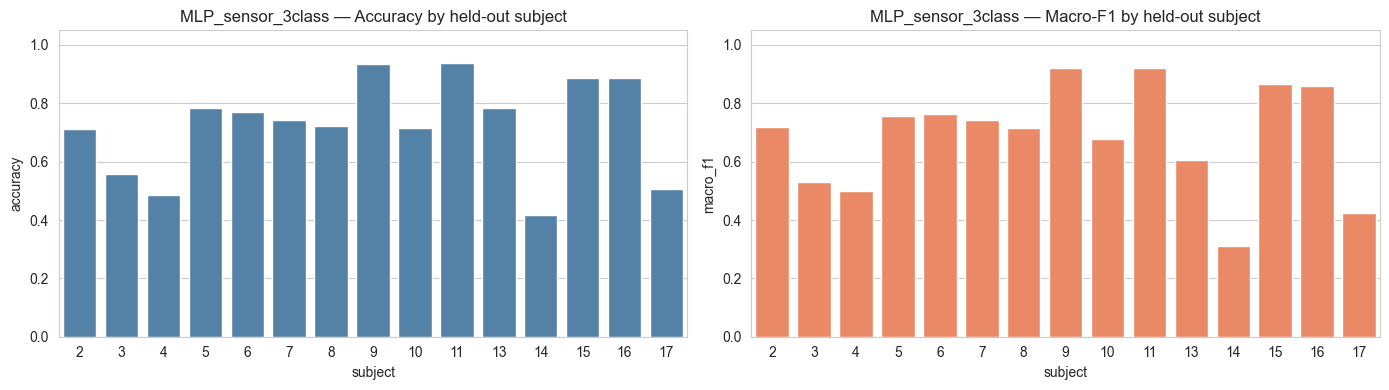

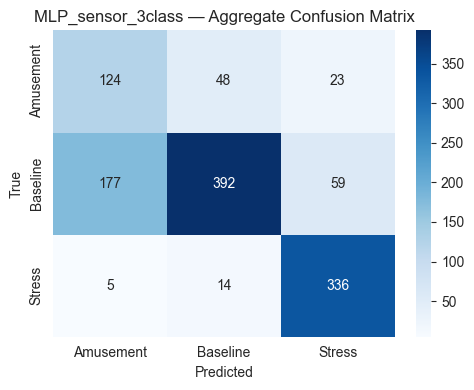

In [48]:
print('MLP — 3-class (sensor features)')
res_mlp_3c = loso_mlp(df_sensor, SENSOR_FEATS, 'label', num_classes=3, binary=False)
print_results('MLP_sensor_3class', res_mlp_3c, MULTI_NAMES)
plot_loso_bars(res_mlp_3c, 'MLP_sensor_3class')
plot_confusion(res_mlp_3c, 'MLP_sensor_3class', MULTI_NAMES)

MLP — Binary (sensor features)
  S 2  acc=0.974  f1=0.967
  S 3  acc=0.636  f1=0.636
  S 4  acc=0.974  f1=0.968
  S 5  acc=0.987  f1=0.985
  S 6  acc=1.000  f1=1.000
  S 7  acc=0.987  f1=0.985
  S 8  acc=0.962  f1=0.957
  S 9  acc=1.000  f1=1.000
  S10  acc=1.000  f1=1.000
  S11  acc=0.987  f1=0.985
  S13  acc=1.000  f1=1.000
  S14  acc=0.481  f1=0.473
  S15  acc=0.975  f1=0.969
  S16  acc=1.000  f1=1.000
  S17  acc=0.494  f1=0.478

 MLP_sensor_binary
  Mean Accuracy : 0.8971 ± 0.1896
  Mean Macro-F1 : 0.8935 ± 0.1924

              precision    recall  f1-score   support

  Not-Stress      0.974     0.875     0.922       823
      Stress      0.765     0.946     0.846       355

    accuracy                          0.896      1178
   macro avg      0.870     0.911     0.884      1178
weighted avg      0.911     0.896     0.899      1178



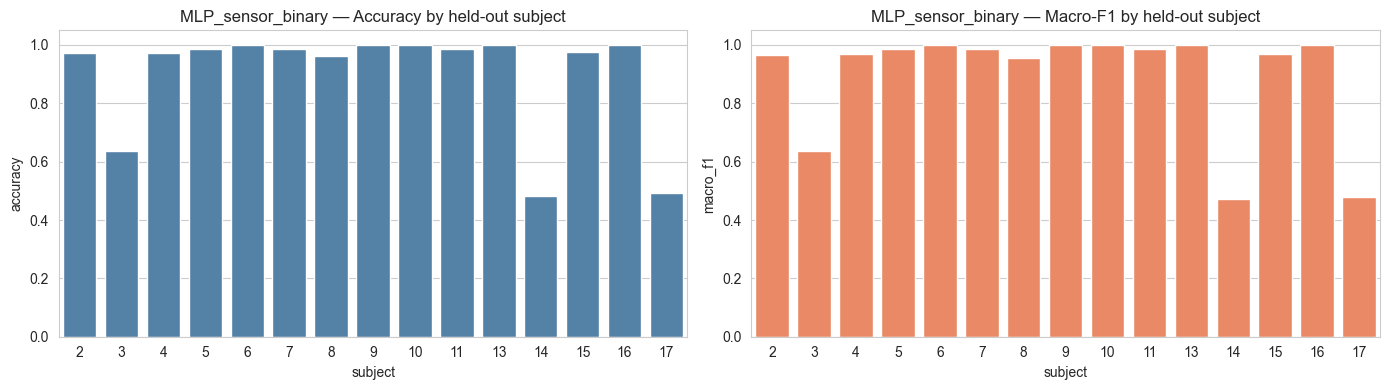

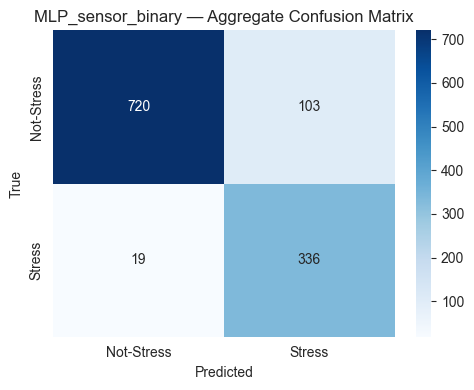

In [49]:
print('MLP — Binary (sensor features)')
res_mlp_bin = loso_mlp(df_sensor, SENSOR_FEATS, 'label', num_classes=2, binary=True)
print_results('MLP_sensor_binary', res_mlp_bin, BIN_NAMES)
plot_loso_bars(res_mlp_bin, 'MLP_sensor_binary')
plot_confusion(res_mlp_bin, 'MLP_sensor_binary', BIN_NAMES)

MLP — 3-class (sensor + demographics)
  S 2  acc=0.526  f1=0.553
  S 3  acc=0.468  f1=0.467
  S 4  acc=0.724  f1=0.586
  S 5  acc=0.633  f1=0.405
  S 6  acc=0.564  f1=0.587
  S 7  acc=0.808  f1=0.804
  S 8  acc=0.759  f1=0.663
  S 9  acc=0.987  f1=0.983
  S10  acc=0.753  f1=0.738
  S11  acc=0.747  f1=0.703
  S13  acc=0.759  f1=0.577
  S14  acc=0.709  f1=0.512
  S15  acc=0.646  f1=0.663
  S16  acc=0.519  f1=0.527
  S17  acc=0.556  f1=0.522

 MLP_sensor+demo_3class
  Mean Accuracy : 0.6772 ± 0.1370
  Mean Macro-F1 : 0.6193 ± 0.1460

              precision    recall  f1-score   support

   Amusement      0.368     0.595     0.455       195
    Baseline      0.785     0.616     0.690       628
      Stress      0.797     0.831     0.814       355

    accuracy                          0.677      1178
   macro avg      0.650     0.681     0.653      1178
weighted avg      0.720     0.677     0.689      1178



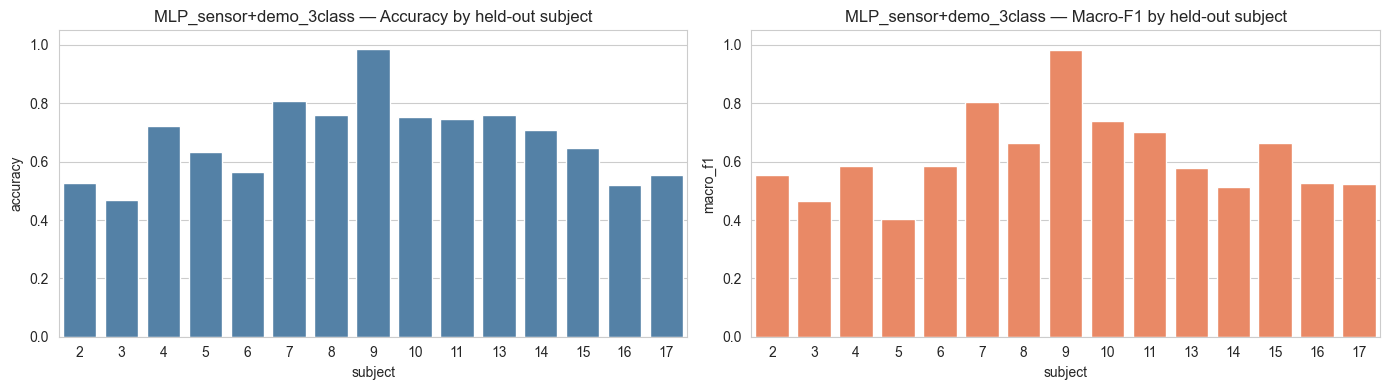

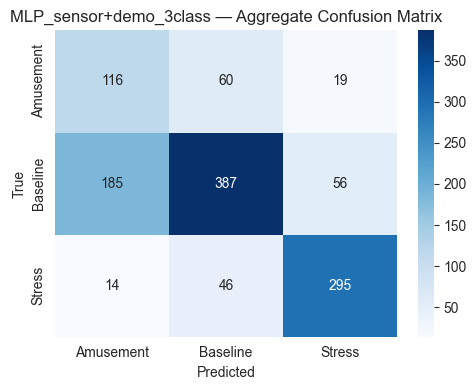

In [50]:
print('MLP — 3-class (sensor + demographics)')
res_mlp_3c_demo = loso_mlp(df_merged, SENSOR_PLUS_DEMO, 'label', num_classes=3, binary=False)
print_results('MLP_sensor+demo_3class', res_mlp_3c_demo, MULTI_NAMES)
plot_loso_bars(res_mlp_3c_demo, 'MLP_sensor+demo_3class')
plot_confusion(res_mlp_3c_demo, 'MLP_sensor+demo_3class', MULTI_NAMES)

MLP — Binary (sensor + demographics)
  S 2  acc=0.987  f1=0.984
  S 3  acc=0.649  f1=0.641
  S 4  acc=0.987  f1=0.984
  S 5  acc=0.987  f1=0.984
  S 6  acc=1.000  f1=1.000
  S 7  acc=0.974  f1=0.970
  S 8  acc=0.975  f1=0.971
  S 9  acc=1.000  f1=1.000
  S10  acc=1.000  f1=1.000
  S11  acc=0.873  f1=0.833
  S13  acc=1.000  f1=1.000
  S14  acc=0.696  f1=0.692
  S15  acc=0.987  f1=0.985
  S16  acc=1.000  f1=1.000
  S17  acc=0.802  f1=0.773

 MLP_sensor+demo_binary
  Mean Accuracy : 0.9279 ± 0.1178
  Mean Macro-F1 : 0.9212 ± 0.1233

              precision    recall  f1-score   support

  Not-Stress      0.969     0.926     0.947       823
      Stress      0.844     0.932     0.886       355

    accuracy                          0.928      1178
   macro avg      0.907     0.929     0.917      1178
weighted avg      0.932     0.928     0.929      1178



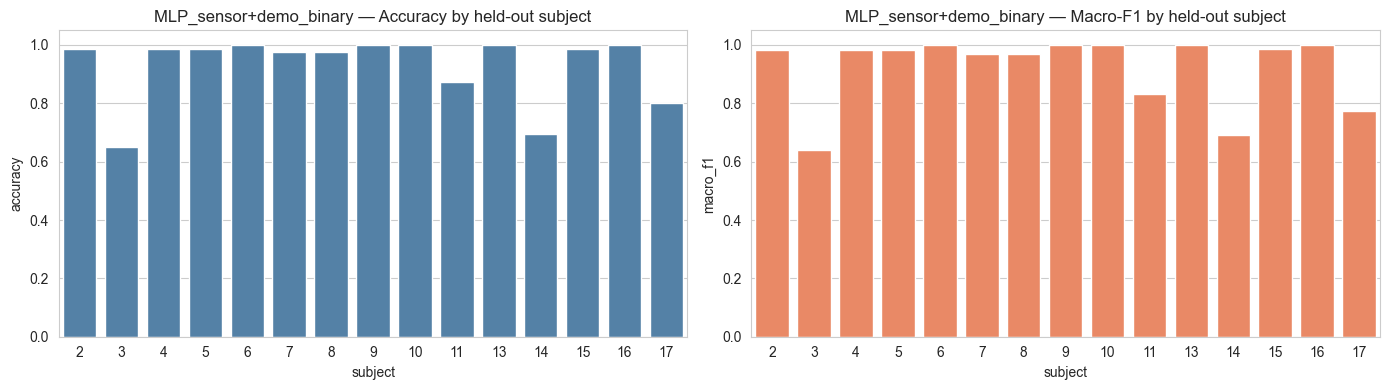

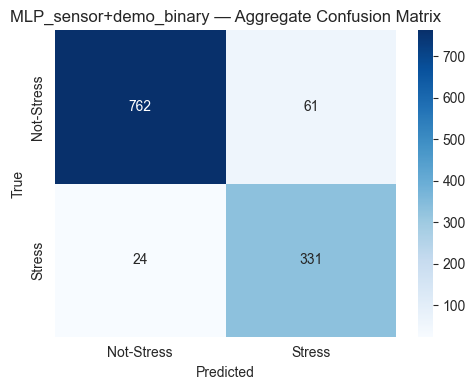

In [51]:
print('MLP — Binary (sensor + demographics)')
res_mlp_bin_demo = loso_mlp(df_merged, SENSOR_PLUS_DEMO, 'label', num_classes=2, binary=True)
print_results('MLP_sensor+demo_binary', res_mlp_bin_demo, BIN_NAMES)
plot_loso_bars(res_mlp_bin_demo, 'MLP_sensor+demo_binary')
plot_confusion(res_mlp_bin_demo, 'MLP_sensor+demo_binary', BIN_NAMES)

### A.7 — Summary Comparison Table

In [52]:
all_results = {}
all_results.update(sklearn_results_multi)
all_results.update(sklearn_results_bin)
all_results['MLP_sensor_3class'] = res_mlp_3c
all_results['MLP_sensor_binary'] = res_mlp_bin
all_results['MLP_sensor+demo_3class'] = res_mlp_3c_demo
all_results['MLP_sensor+demo_binary'] = res_mlp_bin_demo

summary_rows = []
for key, res in all_results.items():
    summary_rows.append({
        'Experiment': key,
        'Mean Acc': f"{res['mean_acc']:.3f} ± {res['std_acc']:.3f}",
        'Mean F1':  f"{res['mean_f1']:.3f} ± {res['std_f1']:.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Experiment,Mean Acc,Mean F1
0,LogReg_sensor_3class,0.719 ± 0.172,0.588 ± 0.180
1,LogReg_sensor+demo_3class,0.717 ± 0.167,0.607 ± 0.181
2,RandomForest_sensor_3class,0.731 ± 0.205,0.663 ± 0.230
3,RandomForest_sensor+demo_3class,0.737 ± 0.194,0.664 ± 0.223
4,XGBoost_sensor_3class,0.736 ± 0.205,0.677 ± 0.235
5,XGBoost_sensor+demo_3class,0.742 ± 0.192,0.663 ± 0.223
6,LogReg_sensor_binary,0.886 ± 0.161,0.866 ± 0.188
7,LogReg_sensor+demo_binary,0.873 ± 0.162,0.853 ± 0.177
8,RandomForest_sensor_binary,0.865 ± 0.214,0.837 ± 0.244
9,RandomForest_sensor+demo_binary,0.878 ± 0.205,0.851 ± 0.238


---
# PART B — RNN on Raw Time-Series

This section loads the original WESAD `.pkl` files, extracts wrist sensor streams (EDA, BVP, TEMP, ACC), resamples them to a common frequency, segments into fixed-length windows, and trains a GRU classifier with LOSO evaluation.

**Prerequisite**: Place the WESAD `.pkl` files so each subject is at  
`data/WESAD/S{id}/S{id}.pkl` (e.g. `data/WESAD/S2/S2.pkl`).

### B.1 — Configuration

In [21]:
WESAD_ROOT = Path('data') / 'WESAD'
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

# Wrist sampling frequencies
FS_WRIST = {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}
FS_LABEL = 700

# Resample everything to this common frequency (Hz)
TARGET_FS = 4

# Window length for RNN input (in seconds)
RNN_WINDOW_SEC = 30
# => each window = TARGET_FS * RNN_WINDOW_SEC = 120 time steps
RNN_SEQ_LEN = TARGET_FS * RNN_WINDOW_SEC

# Keep only labels 1 (baseline), 2 (stress), 3 (amusement)
VALID_LABELS = {1, 2, 3}

# Map to 0-indexed: 1->Baseline(1), 2->Stress(2), 3->Amusement(0)
RAW_LABEL_TO_IDX = {1: 1, 2: 2, 3: 0}

print(f'Sequence length  : {RNN_SEQ_LEN} steps ({RNN_WINDOW_SEC}s @ {TARGET_FS}Hz)')
print(f'Feature channels : EDA, BVP, TEMP, ACC_x, ACC_y, ACC_z = 6')

Sequence length  : 120 steps (30s @ 4Hz)
Feature channels : EDA, BVP, TEMP, ACC_x, ACC_y, ACC_z = 6


### B.2 — Load & Resample Raw Signals

In [22]:
from scipy.signal import resample


def load_subject_raw(wesad_root, subject_id):
    """Load a single subject's pkl and return resampled arrays + labels."""
    name = f'S{subject_id}'
    pkl_path = wesad_root / name / f'{name}.pkl'
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    wrist = data['signal']['wrist']
    labels = np.asarray(data['label']).reshape(-1)

    # Total duration in seconds (from label stream, the highest-rate signal)
    total_sec = len(labels) / FS_LABEL
    n_target = int(total_sec * TARGET_FS)

    # Resample each wrist signal to TARGET_FS
    eda = resample(np.asarray(wrist['EDA']).reshape(-1), n_target)
    bvp = resample(np.asarray(wrist['BVP']).reshape(-1), n_target)
    temp = resample(np.asarray(wrist['TEMP']).reshape(-1), n_target)
    acc = np.asarray(wrist['ACC'])
    if acc.ndim == 1:
        acc = acc.reshape(-1, 1)
    acc_x = resample(acc[:, 0], n_target)
    acc_y = resample(acc[:, 1], n_target)
    acc_z = resample(acc[:, 2], n_target)

    # Resample labels (nearest-neighbour via repeat + subsample)
    label_indices = np.linspace(0, len(labels) - 1, n_target).astype(int)
    labels_resampled = labels[label_indices]

    # Stack: (n_target, 6)
    signals = np.stack([eda, bvp, temp, acc_x, acc_y, acc_z], axis=1)
    return signals, labels_resampled


def segment_subject(signals, labels, seq_len, valid_labels, label_map):
    """
    Cut the resampled stream into non-overlapping windows of `seq_len`.
    Only keep windows where the majority label is in `valid_labels`.
    Returns X (n_windows, seq_len, n_channels), y (n_windows,).
    """
    n_windows = len(signals) // seq_len
    X_list, y_list = [], []

    for i in range(n_windows):
        start = i * seq_len
        end = start + seq_len
        seg_labels = labels[start:end]

        # Majority vote label for this window
        vals, cnts = np.unique(seg_labels, return_counts=True)
        majority = vals[cnts.argmax()]

        if majority not in valid_labels:
            continue

        X_list.append(signals[start:end])
        y_list.append(label_map[majority])

    if len(X_list) == 0:
        return np.empty((0, seq_len, signals.shape[1])), np.empty((0,), dtype=int)

    return np.array(X_list), np.array(y_list)

In [23]:
# Check if pkl files exist before trying to load
pkl_available = all(
    (WESAD_ROOT / f'S{sid}' / f'S{sid}.pkl').exists() for sid in SUBJECT_IDS
)

if not pkl_available:
    missing = [sid for sid in SUBJECT_IDS
               if not (WESAD_ROOT / f'S{sid}' / f'S{sid}.pkl').exists()]
    print(f'⚠ Missing pkl files for subjects: {missing}')
    print(f'  Expected path pattern: {WESAD_ROOT}/S{{id}}/S{{id}}.pkl')
    print('  Download from: https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx')
    print('  Place the extracted folders so the paths above exist.')
    print('\n  Skipping Part B — RNN pipeline.')
else:
    print(f'All {len(SUBJECT_IDS)} subject pkl files found. Loading...')

All 15 subject pkl files found. Loading...


In [15]:
if pkl_available:
    subject_data = {}  # {subject_id: (X, y)}
    for sid in SUBJECT_IDS:
        signals, labels = load_subject_raw(WESAD_ROOT, sid)
        X, y = segment_subject(signals, labels, RNN_SEQ_LEN, VALID_LABELS, RAW_LABEL_TO_IDX)
        subject_data[sid] = (X, y)
        print(f'  S{sid:>2d}: {X.shape[0]:>3d} windows  '
              f'(Amu={np.sum(y==0)}, Bas={np.sum(y==1)}, Str={np.sum(y==2)})')

    total_windows = sum(v[0].shape[0] for v in subject_data.values())
    print(f'\nTotal windows: {total_windows}')

  S 2:  70 windows  (Amu=12, Bas=38, Str=20)
  S 3:  71 windows  (Amu=12, Bas=38, Str=21)
  S 4:  72 windows  (Amu=12, Bas=38, Str=22)
  S 5:  75 windows  (Amu=13, Bas=40, Str=22)
  S 6:  74 windows  (Amu=12, Bas=40, Str=22)
  S 7:  74 windows  (Amu=12, Bas=40, Str=22)
  S 8:  74 windows  (Amu=13, Bas=39, Str=22)
  S 9:  74 windows  (Amu=13, Bas=39, Str=22)
  S10:  77 windows  (Amu=13, Bas=39, Str=25)
  S11:  73 windows  (Amu=12, Bas=39, Str=22)
  S13:  74 windows  (Amu=13, Bas=39, Str=22)
  S14:  74 windows  (Amu=12, Bas=39, Str=23)
  S15:  74 windows  (Amu=12, Bas=39, Str=23)
  S16:  75 windows  (Amu=12, Bas=40, Str=23)
  S17:  75 windows  (Amu=12, Bas=39, Str=24)

Total windows: 1106


### B.3 — Sequence Dataset & GRU Model

In [16]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class StressGRU(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, num_layers=2,
                 num_classes=3, dropout=0.3, bidirectional=False):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        fc_in = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fc_in, num_classes),
        )

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        out, _ = self.gru(x)
        # Use the last hidden state
        last = out[:, -1, :]
        return self.head(last)


class StressLSTM(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, num_layers=2,
                 num_classes=3, dropout=0.3, bidirectional=False):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        fc_in = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fc_in, num_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)

In [17]:
class ResidualBlock(nn.Module):
    """A single 1D residual block: Conv-BN-ReLU-Conv-BN + skip connection."""
    def __init__(self, channels, kernel_size=7, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class StressResNet(nn.Module):
    """
    1D-ResNet for time-series classification.
    Input: (batch, seq_len, input_dim) — same convention as the RNN models.
    """
    def __init__(self, input_dim=6, num_classes=3, n_filters=64,
                 n_blocks=3, dropout=0.3, **kwargs):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(input_dim, n_filters, kernel_size=7, padding=3),
            nn.BatchNorm1d(n_filters),
            nn.ReLU(),
        )
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(n_filters, kernel_size=7, dropout=dropout)
              for _ in range(n_blocks)]
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(n_filters, num_classes),
        )

    def forward(self, x):
        # x: (batch, seq_len, channels) -> (batch, channels, seq_len)
        x = x.permute(0, 2, 1)
        x = self.input_proj(x)
        x = self.res_blocks(x)
        return self.head(x)

### B.4 — LOSO Training & Evaluation for RNN

In [18]:
def per_channel_standardise(X_train, X_test):
    """
    Standardise each of the 6 channels independently.
    X has shape (n_windows, seq_len, n_channels).
    """
    n_ch = X_train.shape[2]
    means = np.zeros(n_ch)
    stds = np.zeros(n_ch)
    for c in range(n_ch):
        flat = X_train[:, :, c].ravel()
        means[c] = flat.mean()
        stds[c] = flat.std() + 1e-8
    X_train_out = (X_train - means) / stds
    X_test_out = (X_test - means) / stds
    return X_train_out, X_test_out


def loso_rnn(subject_data, model_class, num_classes=3, binary=False,
             lr=1e-3, epochs=60, batch_size=16, verbose_every=5, **model_kwargs):
    """
    LOSO evaluation for an RNN model.
    subject_data: {subject_id: (X, y)} where X is (n, seq_len, n_ch).
    """
    subjects = sorted(subject_data.keys())
    fold_metrics = []
    all_y_true, all_y_pred = [], []

    for test_subj in subjects:
        # Build train/test
        X_trains = [subject_data[s][0] for s in subjects if s != test_subj]
        y_trains = [subject_data[s][1] for s in subjects if s != test_subj]
        X_train = np.concatenate(X_trains)
        y_train = np.concatenate(y_trains)
        X_test, y_test = subject_data[test_subj]

        if binary:
            y_train = to_binary(y_train)
            y_test = to_binary(y_test)

        if len(X_test) == 0:
            print(f'  S{test_subj:>2d}: no test windows — skipping')
            continue

        X_train, X_test = per_channel_standardise(X_train, X_test)

        # Class weights
        classes, counts = np.unique(y_train, return_counts=True)
        weights = torch.tensor(1.0 / counts, dtype=torch.float32)
        weights = weights / weights.sum() * len(classes)

        train_loader = DataLoader(SequenceDataset(X_train, y_train),
                                  batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(SequenceDataset(X_test, y_test),
                                 batch_size=len(X_test))

        n_classes = num_classes if not binary else 2
        model = model_class(
            input_dim=X_train.shape[2], num_classes=n_classes, **model_kwargs
        ).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        print(f'\nTraining fold with S{test_subj} held out...')

        # Train
        model.train()
        for epoch in range(epochs):
            running_loss = 0.0
            running_total = 0

            for X_b, y_b in train_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(X_b), y_b)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * X_b.size(0)
                running_total += y_b.size(0)

            epoch_loss = running_loss / running_total
            if ((epoch + 1) % verbose_every == 0) or (epoch == 0) or (epoch == epochs - 1):
                print(f'    epoch {epoch + 1:>3d}/{epochs}  loss={epoch_loss:.4f}')

        # Evaluate
        model.eval()
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(DEVICE)
                preds = model(X_b).argmax(dim=1).cpu().numpy()
                y_true = y_b.numpy()

        acc = accuracy_score(y_true, preds)
        f1 = f1_score(y_true, preds, average='macro')
        fold_metrics.append({'subject': test_subj, 'accuracy': acc, 'macro_f1': f1})
        all_y_true.extend(y_true)
        all_y_pred.extend(preds)
        print(f'  S{test_subj:>2d}  acc={acc:.3f}  f1={f1:.3f}')

    metrics_df = pd.DataFrame(fold_metrics)
    return {
        'per_fold': metrics_df,
        'mean_acc': metrics_df['accuracy'].mean(),
        'std_acc': metrics_df['accuracy'].std(),
        'mean_f1': metrics_df['macro_f1'].mean(),
        'std_f1': metrics_df['macro_f1'].std(),
        'y_true': np.array(all_y_true),
        'y_pred': np.array(all_y_pred),
    }

### B.5 — Run GRU (3-class)

GRU — 3-class

Training fold with S2 held out...
    epoch   1/60  loss=0.9940
    epoch   5/60  loss=0.6973
    epoch  10/60  loss=0.6032
    epoch  15/60  loss=0.4042
    epoch  20/60  loss=0.2808
    epoch  25/60  loss=0.2508
    epoch  30/60  loss=0.2078
    epoch  35/60  loss=0.2570
    epoch  40/60  loss=0.1763
    epoch  45/60  loss=0.1008
    epoch  50/60  loss=0.1483
    epoch  55/60  loss=0.1674
    epoch  60/60  loss=0.0496
  S 2  acc=0.657  f1=0.528

Training fold with S3 held out...
    epoch   1/60  loss=0.9946
    epoch   5/60  loss=0.6727
    epoch  10/60  loss=0.4903
    epoch  15/60  loss=0.7170
    epoch  20/60  loss=0.3919
    epoch  25/60  loss=0.3349
    epoch  30/60  loss=0.2478
    epoch  35/60  loss=0.1719
    epoch  40/60  loss=0.3321
    epoch  45/60  loss=0.2784
    epoch  50/60  loss=0.2760
    epoch  55/60  loss=0.1926
    epoch  60/60  loss=0.1508
  S 3  acc=0.380  f1=0.303

Training fold with S4 held out...
    epoch   1/60  loss=0.9985
    epoch   5/60 

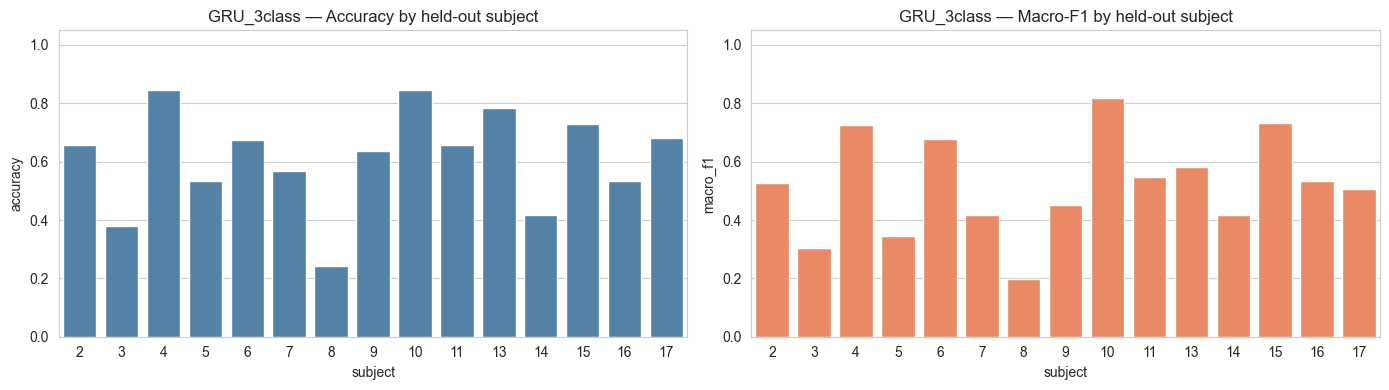

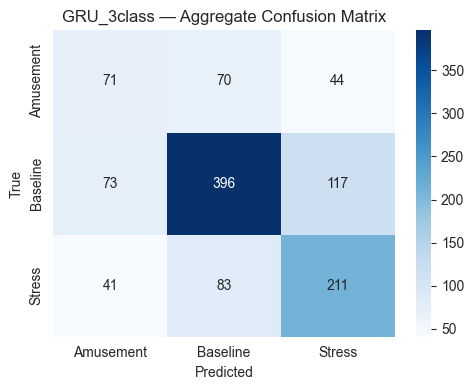

In [29]:
if pkl_available:
    print('GRU — 3-class')
    res_gru_3c = loso_rnn(
        subject_data, StressGRU, num_classes=3, binary=False,
        hidden_dim=64, num_layers=2, dropout=0.3,
        lr=1e-3, epochs=60, batch_size=16,
    )
    print_results('GRU_3class', res_gru_3c, MULTI_NAMES)
    plot_loso_bars(res_gru_3c, 'GRU_3class')
    plot_confusion(res_gru_3c, 'GRU_3class', MULTI_NAMES)

### B.6 — Run GRU (Binary: Stress vs Rest)

GRU — Binary

Training fold with S2 held out...
    epoch   1/60  loss=0.5928
    epoch   5/60  loss=0.3132
    epoch  10/60  loss=0.1937
    epoch  15/60  loss=0.1051
    epoch  20/60  loss=0.2063
    epoch  25/60  loss=0.2038
    epoch  30/60  loss=0.1245
    epoch  35/60  loss=0.0700
    epoch  40/60  loss=0.0363
    epoch  45/60  loss=0.0898
    epoch  50/60  loss=0.0164
    epoch  55/60  loss=0.0159
    epoch  60/60  loss=0.0051
  S 2  acc=0.800  f1=0.669

Training fold with S3 held out...
    epoch   1/60  loss=0.5849
    epoch   5/60  loss=0.3224
    epoch  10/60  loss=0.2484
    epoch  15/60  loss=0.2394
    epoch  20/60  loss=0.1179
    epoch  25/60  loss=0.1728
    epoch  30/60  loss=0.0833
    epoch  35/60  loss=0.0203
    epoch  40/60  loss=0.2084
    epoch  45/60  loss=0.0121
    epoch  50/60  loss=0.0253
    epoch  55/60  loss=0.0022
    epoch  60/60  loss=0.0008
  S 3  acc=0.732  f1=0.718

Training fold with S4 held out...
    epoch   1/60  loss=0.5962
    epoch   5/60  

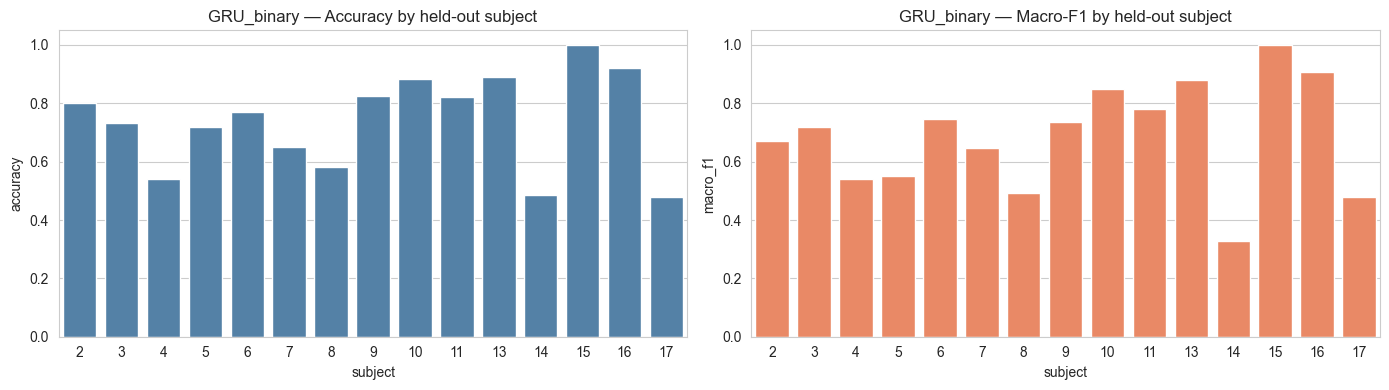

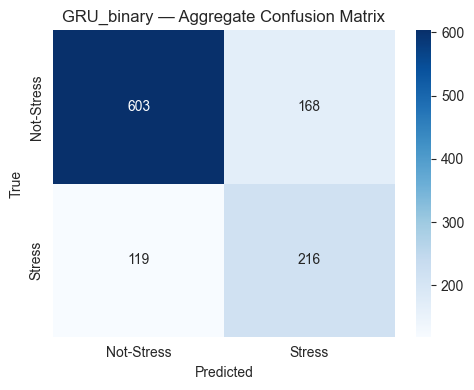

In [26]:
if pkl_available:
    print('GRU — Binary')
    res_gru_bin = loso_rnn(
        subject_data, StressGRU, num_classes=2, binary=True,
        hidden_dim=64, num_layers=2, dropout=0.3,
        lr=1e-3, epochs=60, batch_size=16,
    )
    print_results('GRU_binary', res_gru_bin, BIN_NAMES)
    plot_loso_bars(res_gru_bin, 'GRU_binary')
    plot_confusion(res_gru_bin, 'GRU_binary', BIN_NAMES)

### B.7 — Run LSTM (3-class)

LSTM — 3-class

Training fold with S2 held out...
    epoch   1/60  loss=1.0216
    epoch   5/60  loss=0.6858
    epoch  10/60  loss=0.7718
    epoch  15/60  loss=0.5130
    epoch  20/60  loss=0.4650
    epoch  25/60  loss=0.3825
    epoch  30/60  loss=0.4714
    epoch  35/60  loss=0.7134
    epoch  40/60  loss=0.5338
    epoch  45/60  loss=0.6112
    epoch  50/60  loss=0.3752
    epoch  55/60  loss=0.3761
    epoch  60/60  loss=0.5603
  S 2  acc=0.671  f1=0.522

Training fold with S3 held out...
    epoch   1/60  loss=1.0172
    epoch   5/60  loss=0.5769
    epoch  10/60  loss=0.6184
    epoch  15/60  loss=0.4189
    epoch  20/60  loss=0.5484
    epoch  25/60  loss=0.4346
    epoch  30/60  loss=0.5020
    epoch  35/60  loss=0.4668
    epoch  40/60  loss=0.4196
    epoch  45/60  loss=0.2876
    epoch  50/60  loss=0.2766
    epoch  55/60  loss=0.3905
    epoch  60/60  loss=0.2223
  S 3  acc=0.239  f1=0.231

Training fold with S4 held out...
    epoch   1/60  loss=1.0296
    epoch   5/60

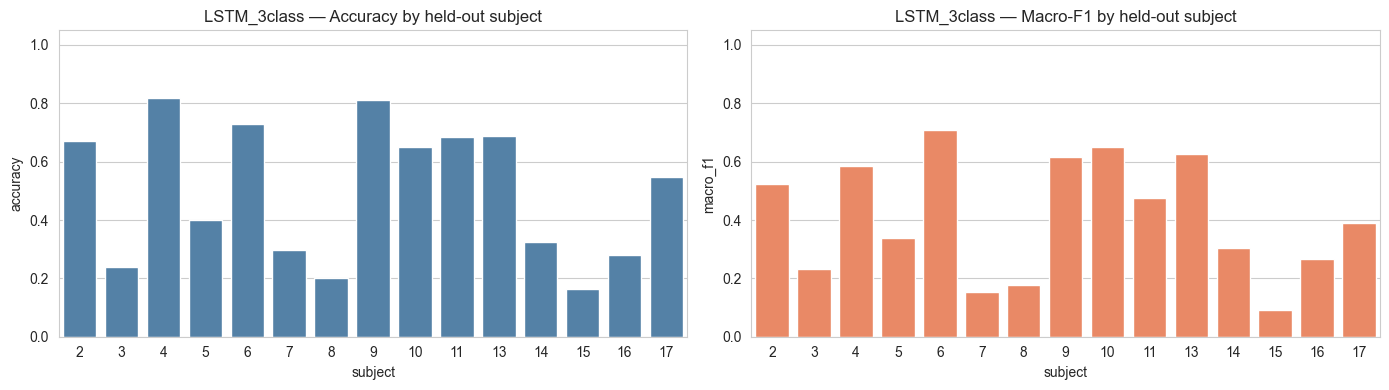

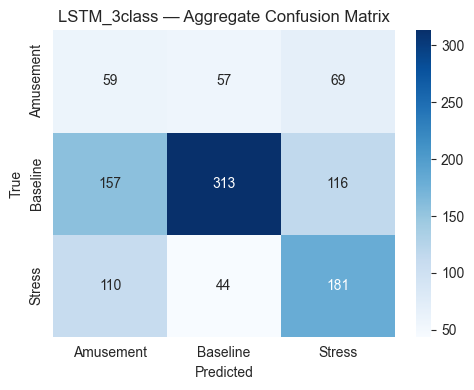

In [27]:
if pkl_available:
    print('LSTM — 3-class')
    res_lstm_3c = loso_rnn(
        subject_data, StressLSTM, num_classes=3, binary=False,
        hidden_dim=64, num_layers=2, dropout=0.3,
        lr=1e-3, epochs=60, batch_size=16,
    )
    print_results('LSTM_3class', res_lstm_3c, MULTI_NAMES)
    plot_loso_bars(res_lstm_3c, 'LSTM_3class')
    plot_confusion(res_lstm_3c, 'LSTM_3class', MULTI_NAMES)

### B.8 — Run LSTM (Binary)

LSTM — Binary

Training fold with S2 held out...
    epoch   1/60  loss=0.6041
    epoch   5/60  loss=0.2914
    epoch  10/60  loss=0.2464
    epoch  15/60  loss=0.1521
    epoch  20/60  loss=0.1823
    epoch  25/60  loss=0.2964
    epoch  30/60  loss=0.1713
    epoch  35/60  loss=0.1191
    epoch  40/60  loss=0.1362
    epoch  45/60  loss=0.1864
    epoch  50/60  loss=0.1048
    epoch  55/60  loss=0.1065
    epoch  60/60  loss=0.0908
  S 2  acc=0.714  f1=0.417

Training fold with S3 held out...
    epoch   1/60  loss=0.5928
    epoch   5/60  loss=0.3376
    epoch  10/60  loss=0.3002
    epoch  15/60  loss=0.4790
    epoch  20/60  loss=0.3756
    epoch  25/60  loss=0.3258
    epoch  30/60  loss=0.2184
    epoch  35/60  loss=0.2288
    epoch  40/60  loss=0.1395
    epoch  45/60  loss=0.1307
    epoch  50/60  loss=0.1118
    epoch  55/60  loss=0.3546
    epoch  60/60  loss=0.2050
  S 3  acc=0.718  f1=0.709

Training fold with S4 held out...
    epoch   1/60  loss=0.5917
    epoch   5/60 

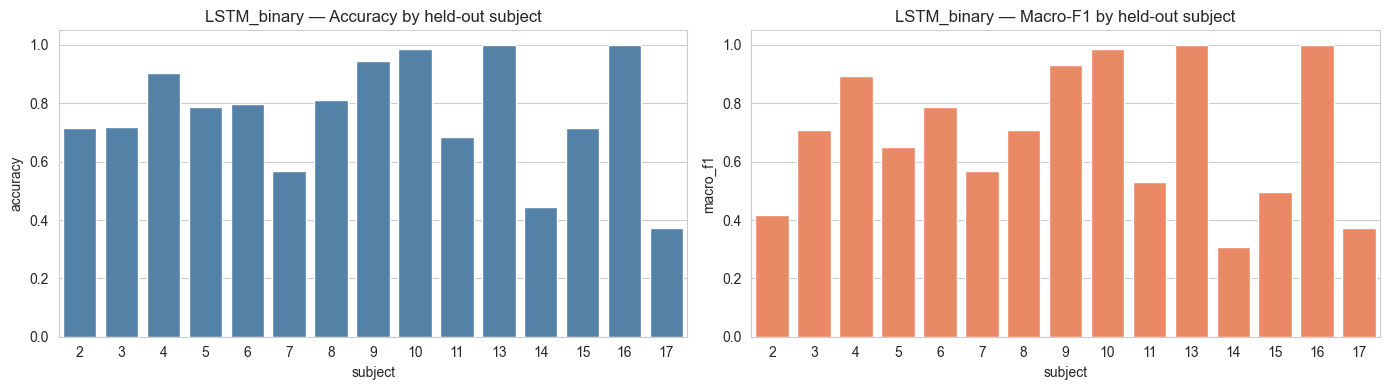

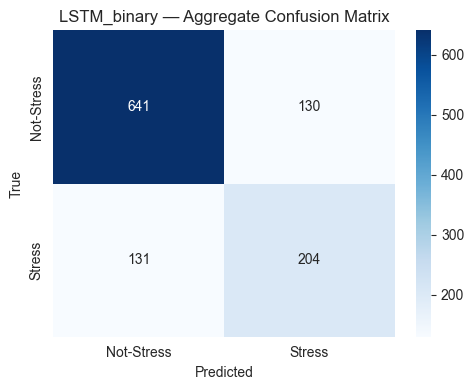

In [28]:
if pkl_available:
    print('LSTM — Binary')
    res_lstm_bin = loso_rnn(
        subject_data, StressLSTM, num_classes=2, binary=True,
        hidden_dim=64, num_layers=2, dropout=0.3,
        lr=1e-3, epochs=60, batch_size=16,
    )
    print_results('LSTM_binary', res_lstm_bin, BIN_NAMES)
    plot_loso_bars(res_lstm_bin, 'LSTM_binary')
    plot_confusion(res_lstm_bin, 'LSTM_binary', BIN_NAMES)

---
### B.9 — 1D-ResNet Model

The ResNet processes the same `(batch, seq_len, 6)` windows as the RNN models but uses stacked 1D convolutional residual blocks instead of recurrence. This allows parallel processing of the full window and captures multi-scale temporal patterns via hierarchical convolutions.

Architecture: input projection (Conv1d → BN → ReLU) → 3 residual blocks (each: Conv-BN-ReLU-Dropout-Conv-BN + skip) → global average pooling → classification head.

### B.10 — Run ResNet (3-class)

ResNet — 3-class

Training fold with S2 held out...
    epoch   1/60  loss=0.9296
    epoch   5/60  loss=0.6819
    epoch  10/60  loss=0.4793
    epoch  15/60  loss=0.4333
    epoch  20/60  loss=0.4010
    epoch  25/60  loss=0.3288
    epoch  30/60  loss=0.2998
    epoch  35/60  loss=0.2850
    epoch  40/60  loss=0.2143
    epoch  45/60  loss=0.2253
    epoch  50/60  loss=0.2463
    epoch  55/60  loss=0.2325
    epoch  60/60  loss=0.2273
  S 2  acc=0.786  f1=0.742

Training fold with S3 held out...
    epoch   1/60  loss=0.8821
    epoch   5/60  loss=0.5978
    epoch  10/60  loss=0.4446
    epoch  15/60  loss=0.4310
    epoch  20/60  loss=0.3476
    epoch  25/60  loss=0.3094
    epoch  30/60  loss=0.3042
    epoch  35/60  loss=0.2763
    epoch  40/60  loss=0.2951
    epoch  45/60  loss=0.2357
    epoch  50/60  loss=0.2433
    epoch  55/60  loss=0.2014
    epoch  60/60  loss=0.1932
  S 3  acc=0.451  f1=0.424

Training fold with S4 held out...
    epoch   1/60  loss=1.0001
    epoch   5/

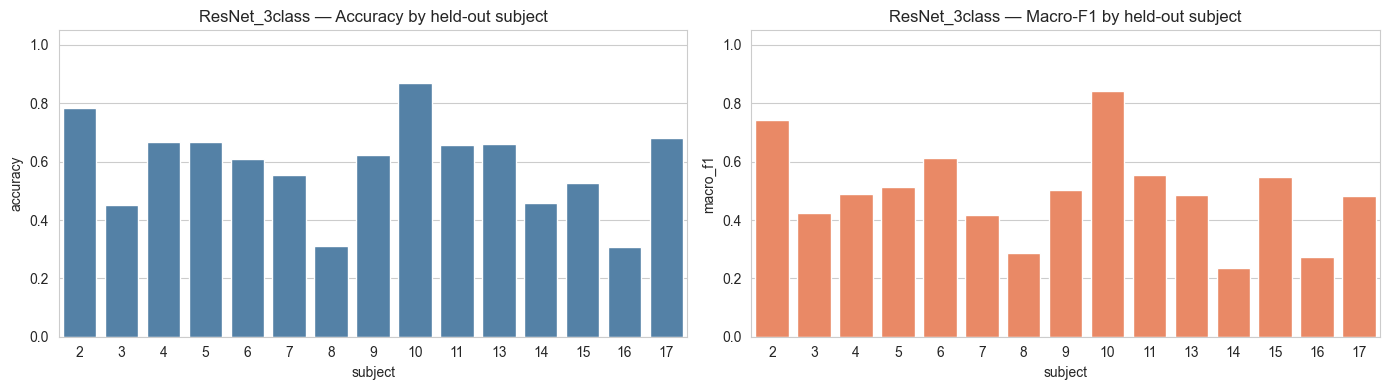

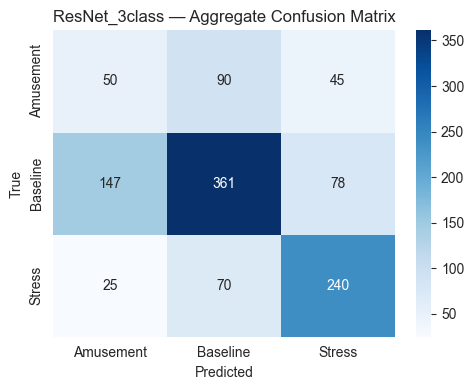

In [32]:
if pkl_available:
    print('ResNet — 3-class')
    res_resnet_3c = loso_rnn(
        subject_data, StressResNet, num_classes=3, binary=False,
        n_filters=64, n_blocks=3, dropout=0.3,
        lr=1e-3, epochs=60, batch_size=16,
    )
    print_results('ResNet_3class', res_resnet_3c, MULTI_NAMES)
    plot_loso_bars(res_resnet_3c, 'ResNet_3class')
    plot_confusion(res_resnet_3c, 'ResNet_3class', MULTI_NAMES)

### B.11 — Run ResNet (Binary: Stress vs Rest)

ResNet — Binary

Training fold with S2 held out...
    epoch   1/60  loss=0.5440
    epoch   5/60  loss=0.2860
    epoch  10/60  loss=0.2380
    epoch  15/60  loss=0.2101
    epoch  20/60  loss=0.1313
    epoch  25/60  loss=0.1498
    epoch  30/60  loss=0.1289
    epoch  35/60  loss=0.1080
    epoch  40/60  loss=0.1138
    epoch  45/60  loss=0.0707
    epoch  50/60  loss=0.0760
    epoch  55/60  loss=0.1279
    epoch  60/60  loss=0.0896
  S 2  acc=0.800  f1=0.669

Training fold with S3 held out...
    epoch   1/60  loss=0.4957
    epoch   5/60  loss=0.2849
    epoch  10/60  loss=0.1939
    epoch  15/60  loss=0.1512
    epoch  20/60  loss=0.1508
    epoch  25/60  loss=0.0976
    epoch  30/60  loss=0.0770
    epoch  35/60  loss=0.0606
    epoch  40/60  loss=0.0877
    epoch  45/60  loss=0.1259
    epoch  50/60  loss=0.0810
    epoch  55/60  loss=0.0769
    epoch  60/60  loss=0.1355
  S 3  acc=0.634  f1=0.599

Training fold with S4 held out...
    epoch   1/60  loss=0.5354
    epoch   5/6

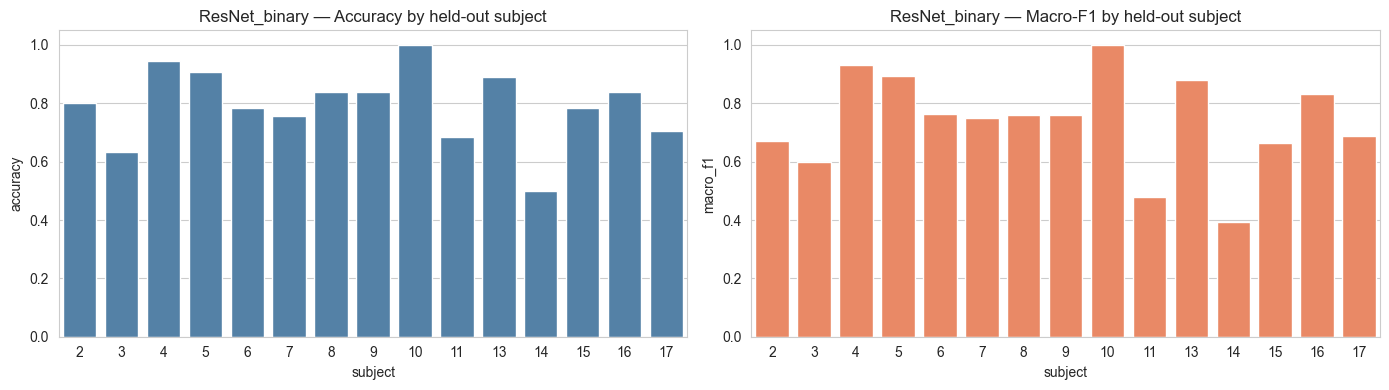

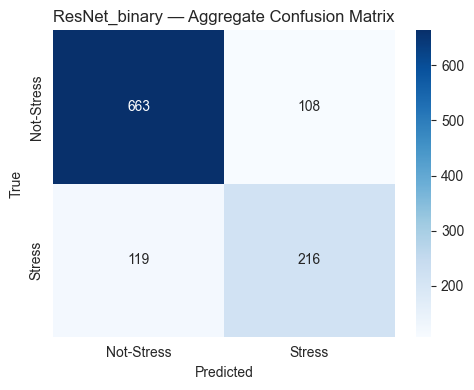

In [33]:
if pkl_available:
    print('ResNet — Binary')
    res_resnet_bin = loso_rnn(
        subject_data, StressResNet, num_classes=2, binary=True,
        n_filters=64, n_blocks=3, dropout=0.3,
        lr=1e-3, epochs=60, batch_size=16,
    )
    print_results('ResNet_binary', res_resnet_bin, BIN_NAMES)
    plot_loso_bars(res_resnet_bin, 'ResNet_binary')
    plot_confusion(res_resnet_bin, 'ResNet_binary', BIN_NAMES)

---
## Final Summary

In [54]:
final_rows = []

for key, res in all_results.items():
    final_rows.append({
        'Experiment': key,
        'Type': 'Tabular',
        'Mean Acc': f"{res['mean_acc']:.3f} ± {res['std_acc']:.3f}",
        'Mean F1':  f"{res['mean_f1']:.3f} ± {res['std_f1']:.3f}",
    })

if pkl_available:
    for name, res in [
        ('GRU_3class', res_gru_3c),
        ('GRU_binary', res_gru_bin),
        ('LSTM_3class', res_lstm_3c),
        ('LSTM_binary', res_lstm_bin),
        ('ResNet_3class', res_resnet_3c),
        ('ResNet_binary', res_resnet_bin),
    ]:
        final_rows.append({
            'Experiment': name,
            'Type': 'Raw sequence',
            'Mean Acc': f"{res['mean_acc']:.3f} ± {res['std_acc']:.3f}",
            'Mean F1':  f"{res['mean_f1']:.3f} ± {res['std_f1']:.3f}",
        })

final_df = pd.DataFrame(final_rows)
final_df

,Experiment,Type,Mean Acc,Mean F1
0,LogReg_sensor_3class,Tabular,0.719 ± 0.172,0.588 ± 0.180
1,LogReg_sensor+demo_3class,Tabular,0.717 ± 0.167,0.607 ± 0.181
2,RandomForest_sensor_3class,Tabular,0.731 ± 0.205,0.663 ± 0.230
3,RandomForest_sensor+demo_3class,Tabular,0.737 ± 0.194,0.664 ± 0.223
4,XGBoost_sensor_3class,Tabular,0.736 ± 0.205,0.677 ± 0.235
5,XGBoost_sensor+demo_3class,Tabular,0.742 ± 0.192,0.663 ± 0.223
6,LogReg_sensor_binary,Tabular,0.886 ± 0.161,0.866 ± 0.188
7,LogReg_sensor+demo_binary,Tabular,0.873 ± 0.162,0.853 ± 0.177
8,RandomForest_sensor_binary,Tabular,0.865 ± 0.214,0.837 ± 0.244
9,RandomForest_sensor+demo_binary,Tabular,0.878 ± 0.205,0.851 ± 0.238
